# Mercy Fantasy Neural Network

## Imports

In [236]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sqlalchemy import create_engine, text
from sklearn.metrics import r2_score

## Database

In [237]:
# Database info
user = "mercyfantasy"
password = "Matthew23"
host = "localhost"
port = "5432"
database = "mercyfantasy"

# create a database connection
engine = create_engine(f"postgresql://{user}:{password}@{host}:{port}/{database}")

In [ ]:
# Data-volume Sanity checks Part 1.C

tables = ['manager_info.managers', 'manager_info.manager_seasons', 'manager_info.matchups', 'manager_info.currentmatchup', 'player_info.detailed_roster', 'player_info.roster_reference', 'transactions.trades', 'transactions.waivers']

for table in tables:
    df = pd.read_sql(f'Select * From {table}', engine.connect())
    print('-', table, 'table has:')
    print(f'     - {df.shape[0]} rows')
    print(f'     - {df.shape[1]} columns')
    print(f'     - {df.isna().sum().sum()} nulls')

- manager_info.managers table has:
     - 12 rows
     - 2 columns
     - 0 nulls
- manager_info.manager_seasons table has:
     - 30 rows
     - 7 columns
     - 0 nulls
- manager_info.matchups table has:
     - 454 rows
     - 17 columns
     - 0 nulls
- manager_info.currentmatchup table has:
     - 10 rows
     - 13 columns
     - 0 nulls
- player_info.detailed_roster table has:
     - 8480 rows
     - 48 columns
     - 0 nulls
- player_info.roster_reference table has:
     - 18430 rows
     - 6 columns
     - 0 nulls
- transactions.trades table has:
     - 258 rows
     - 13 columns
     - 0 nulls
- transactions.waivers table has:
     - 1810 rows
     - 12 columns
     - 0 nulls


We have **no** null rows in our dataset! Our data is in a controlled setting with a robust system (Yahoo fantasy) tracking everything electronically, so makes sense that there are no null values to deal with.

- Managers - Should be 12. We have 10 managers per season, we had one leave and a new one come into the league since inception and one person decided to use two different yahoo accounts, giving him another guid.
- Manager Seasons - 3 years, 10 teams, makes sense.
- Matchups - 3 years (year 3 is ongoing), about 16 games per season (not everyone makes playoffs, so less than 16 per season for all teams) for 10 teams, makes sense.
- Current Matchup - Always 1 game per team each week.
- Detailed Roster - Should be matchups times roster size (can vary with injury reserve, but at least 16), makes sense.
- Roster Reference - This is every single non-defensive player in the NFL since 2023. I would expect this to be much higher than detailed roster since that only contains players on our fantasy teams each week.
- Trades - Looks accurate, trades are not very frequent, but happen often and can involve many players at a time.
- Waivers - Looks accurate, managers will pick up multiple players each week.

In [110]:
# Get training data

fantasy_sql = text('''
Select r.season, r.week, r.player_name, case when NFL.position = 'FB' Then 'RB' else NFL.position end as position, NFL.team as NFL_Team, NFL.opponent_team as NFL_Opposing_Team, r.pass_yds, r.pass_td, r.pass_int, r.rush_att, r.rush_yds, r.rush_td, r.targets, r.rec, r.rec_yds, r.rec_td, r.two_pt_conversion, r.fum_lost, r.points
From player_info.detailed_roster R 
Left Join player_info.roster_reference NFL On R.season = NFL.season and R.week = NFL.week and NFL.player_name = r.player_name
Where r.position_type = 'O'
And (NFL.player_name is not null and r.points != 0) -- Bye week
''')

fantasy = pd.read_sql(fantasy_sql, con=engine.connect())

In [83]:
# Get schedule data for reference in predictions

sql_test = text('''
Select P.Season, sch.week, P.player_name, P.position, P.nfl_team, case when sch.home_team = P.nfl_team then sch.away_team else sch.home_team end as nfl_opposing_team
from player_reference P 
left join nfl_reference sch On P.season = sch.season and (P.nfl_team = sch.home_team or P.nfl_team = sch.away_team)
''')

nfl_reference = pd.read_sql(sql_test, con=engine.connect())

In [84]:
## Roster - Only offensive players that are in the active lineup
trade_sql = text('''
SELECT MM.propername as Manager, T.status, count(distinct trade_id)
FROM transactions.trades T
Left Join manager_info.Manager_seasons M on t.from_team_key = M.team_key
Left Join public.manager_map MM on MM.manager_guid = M.manager_guid
Left Join public.SeasonalPoints P On t.season = p.season and t.player_id = p.player_id
Group By MM.propername, T.status
''')

trades = pd.read_sql(trade_sql, con=engine.connect())

## Data Visualization - Part 4.A

In [ ]:
# Calculate position averages for context
position_avgerages = pd.DataFrame(fantasy.groupby(['position', 'season'])['points'].mean().sort_values(ascending=False)).reset_index()

# Visualize position averages
fig = px.bar(
    position_avgerages,
    x=[f"{row['position']} - {row['season']}" for _, row in position_avgerages.iterrows()],
    y="points",
    color="position",
    title="Seasonal Position Averages",
)

fig.update_layout(
    xaxis_title="Position - Season",
    yaxis_title="Average Points"
)

fig.show()

Across season, Quarterbacks on average score the most points per game (18-19 ppg), then Wide Receivers and Running Backs score almost exactly the same (12-13 ppg), and Tight Ends score the least (11ppg). It may be reasonable to focus least on Tight Ends in this case and most on Quarterbacks.

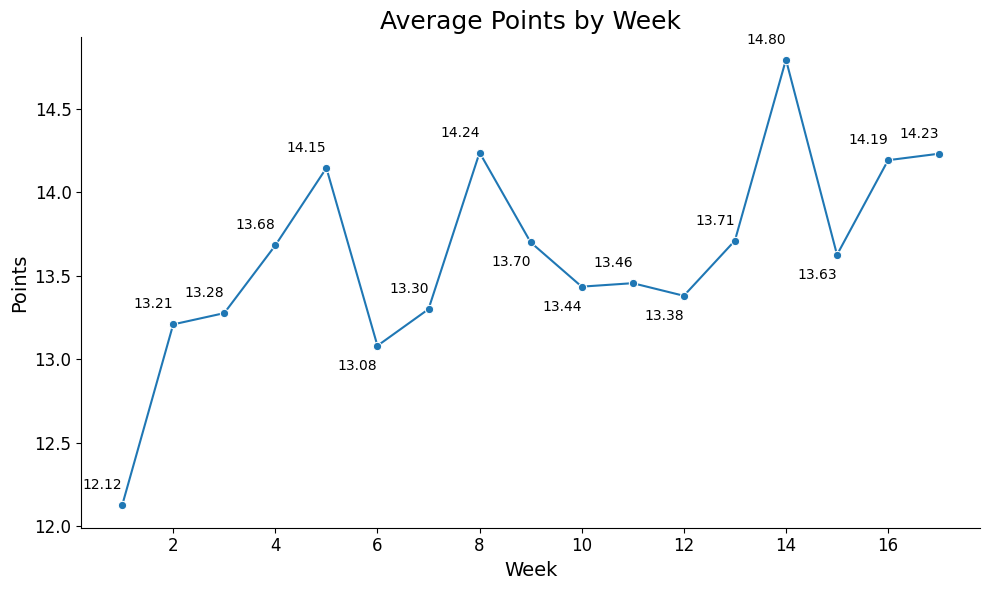

In [13]:
# Get total points by week for context
points_by_week = pd.DataFrame(fantasy.groupby(['week'], observed=True)['points'].mean()).reset_index()

# Create line plot
plt.figure(figsize=(10, 6))

ax = sns.lineplot(data=points_by_week, x='week', y='points', marker="o")

# Annotate differently based on if line is rising or falling
weeks = points_by_week["week"].to_list()
points = points_by_week["points"].to_list()

for i, (x, y) in enumerate(zip(weeks, points)):
    if i == 0:
        offset = 0.12  # first point, place above
    else:
        prev_y = points[i - 1]
        if y > prev_y:
            offset = 0.12  # rising segment → label above
        else:
            offset = -0.12  # falling segment → label below
    
    ax.text(
        x,
        y + offset,
        f"{y:.2f}",
        fontsize=10,
        ha="right",
        va="center"
    )

plt.title("Average Points by Week", fontsize=18)
plt.xlabel("Week", fontsize=14)
plt.ylabel("Points", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

The general trend is that as the season progresses, the scores generally get higher. This makes sense as offenses find their rhythm and generally produce more yards and points. But, the variance is very low across the league since this graph goes from 12.12 at the lowest to 14.80 at the highest.

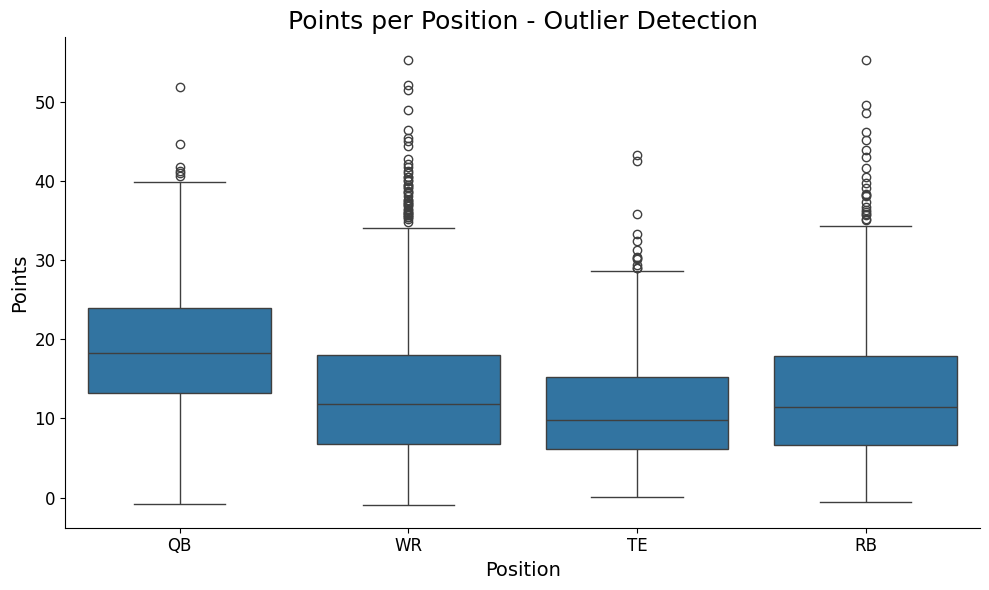

In [14]:
# Create a box plot of points by position
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=fantasy,
    x="position",
    y="points",
)

plt.title("Points per Position - Outlier Detection", fontsize=18)
plt.xlabel("Position", fontsize=14)
plt.ylabel("Points", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

There is pretty similar distributions across positions for points, but at slightly differed positions. The trends in positions from the bar chart above remain the same and also are representative of the upper quartile. QBs score a bit more on average than the rest and TEs score the least. One big insight here is that there are more outliers for WRs and RBs. This may be due to the fact that there are more of them in in a given week (in NFL and the fantasy league), so there is simply more volume and chances for WRs and RBs to have big games.

In [15]:
outlier_rows = []

for pos, group in fantasy.groupby("position"):
    q1 = group["points"].quantile(0.25)
    q3 = group["points"].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Filter group for outliers
    outliers = group[(group["points"] < lower) | (group["points"] > upper)]

    if not outliers.empty:
        outlier_rows.append(outliers)

# Combine across positions
outlier_df = pd.concat(outlier_rows).sort_values(["position", "points"], ascending=[True, False])

outlier_df.reset_index(drop=True)

player_outlier_summary = (
    outlier_df
    .groupby(["player_name", "position"])
    .agg(
        outlier_count=("points", "size"),
        avg_outlier_points=("points", "mean"),
    )
    .reset_index()
    .sort_values(["outlier_count", "avg_outlier_points"], ascending=[False, False])
)

player_outlier_summary.reset_index(drop=True)

,player_name,position,outlier_count,avg_outlier_points
0,Ja'Marr Chase,WR,6,44.766667
1,Josh Allen,QB,4,44.625000
2,Christian McCaffrey,RB,4,41.150000
3,CeeDee Lamb,WR,4,40.075000
4,Jahmyr Gibbs,RB,3,43.466667
5,Jonathan Taylor,RB,3,42.266667
6,Davante Adams,WR,3,40.866667
7,Amon-Ra St Brown,WR,3,38.400000
8,Brock Bowers,TE,3,34.933333
9,Keenan Allen,WR,2,42.980000


Definitely has some outliers. This is the nature of fantasy football though, weird things can happen at any moment. Very low games versus very high games. Since neural network will learn about individual player tendencies as well, makes most sense to leave in all their games for best generalization (these players have high level potential).

The table shows that most of these are great one of games, but a few players have amassed a few outlier games. These are the NFL's biggest stars who can go off for huge games at any moment, winning a manager their matchup in the process.

<Figure size 1000x600 with 0 Axes>

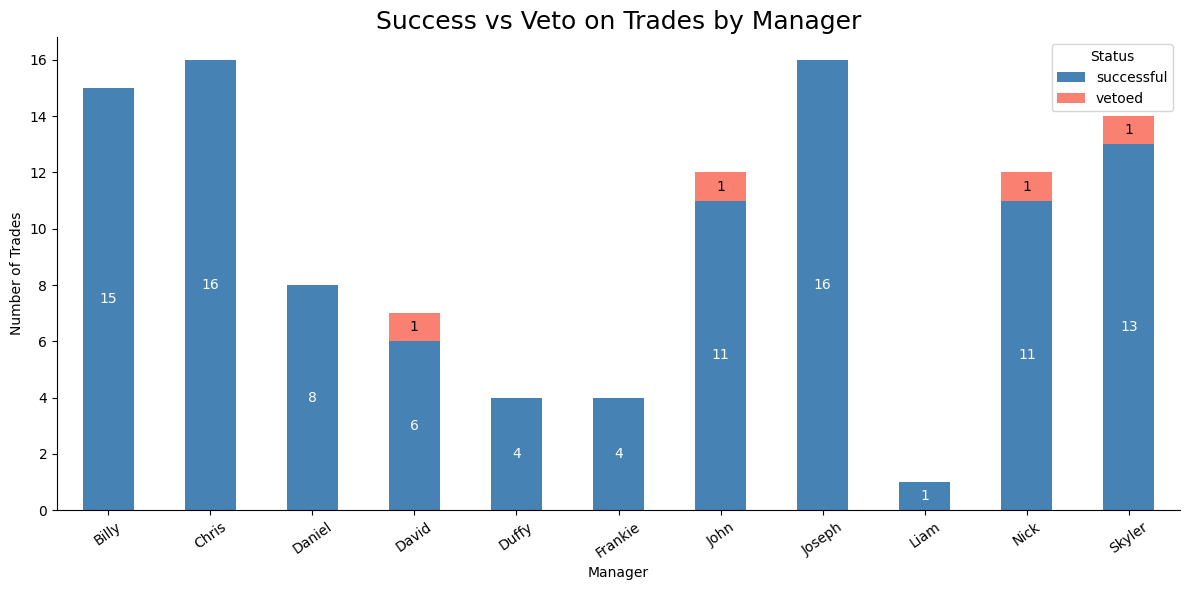

In [16]:
# Gets trades in the same row per manager
pivot = trades.pivot_table(index="manager", columns="status", values="count", fill_value=0)

# Plot a bar chart
plt.figure(figsize=(10, 6))
ax = pivot.plot(kind="bar", stacked=True, figsize=(12,6), color=["steelblue", "salmon"])
plt.title("Success vs Veto on Trades by Manager", fontsize=18)
plt.ylabel("Number of Trades")
plt.xlabel("Manager")
plt.xticks(rotation=35)
plt.legend(title="Status")
plt.tight_layout()
sns.despine()

# Data labels
for i, manager in enumerate(pivot.index):
    success = pivot.loc[manager, "successful"]
    veto = pivot.loc[manager, "vetoed"]
    
    ax.text(
        i,
        success / 2,
        int(success),
        ha="center",
        va="center",
        fontsize=10,
        color="white"
    )
    
    if veto > 0:
        ax.text(
            i,
            success + veto / 2,
            int(veto),
            ha="center",
            va="center",
            fontsize=10,
            color="black",
        )

plt.show()

This a record keeping item. It shows how many trades each manager has done, breaking it down by successful versus vetoed trade. There is no trend with wins compared to number of trades.

## Neural Network - Part 4.B

I am going to use a neural network to predict points for players in my league. This dataset has a lot of categorical variables such as players (hundreds of players), team (32 teams), opponent team, position, week, and season. A neural network will be able to use embeddings to turn these categories into dense vectors that capture the information from these categories. The model needs to understand that some players are highly skilled and that some teams are harder to score against than other (leading to less points for the players going against them). Because of these complexities, a neural network seemed like a good model choice for this use case.

### Data Set Up

In [ ]:
# Split based on future weeks (we want to use past to predict future)
train = fantasy[~((fantasy['season'] == 2025) & (fantasy['week'] > 7))].reset_index(drop=True)
test = fantasy[(fantasy['season'] == 2025) & (fantasy['week'] > 7)].reset_index(drop=True)

In [112]:
# Set up categorical columns
categorical_cols = [
    "player_name",
    "position",
    "nfl_team",
    "nfl_opposing_team",
    "season",
    "week",
]

cat_maps = {}

for col in categorical_cols:
    uniques = train[col].dropna().unique().tolist()
    mapping = {v: i+1 for i, v in enumerate(uniques)}  # 1..N
    mapping["<UNK>"] = 0                               # 0 is unknown
    cat_maps[col] = mapping

In [113]:
def encode_column(values, mapping):
    return np.array([mapping.get(v, 0) for v in values], dtype=np.int64)

# Encode train/test
X_train_np = np.column_stack([
    encode_column(train[col].values, cat_maps[col]) for col in categorical_cols
])

X_test_np = np.column_stack([
    encode_column(test[col].values, cat_maps[col]) for col in categorical_cols
])

y_train_np = train["points"].values.astype("float32")
y_test_np  = test["points"].values.astype("float32")

In [114]:
X_train = torch.tensor(X_train_np, dtype=torch.long)
X_test  = torch.tensor(X_test_np,  dtype=torch.long)

y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test_np,  dtype=torch.float32).unsqueeze(1)

In [115]:
num_players   = max(cat_maps["player_name"].values()) + 1
num_positions = max(cat_maps["position"].values()) + 1
num_teams     = max(cat_maps["nfl_team"].values()) + 1
num_seasons   = max(cat_maps["season"].values()) + 1
num_weeks     = max(cat_maps["week"].values()) + 1

### Training

In [180]:
# Define NN
class SimpleFFModel(nn.Module):
    def __init__(self, num_players, num_positions, num_teams, num_seasons, num_weeks, emb_dim=16):
        super().__init__()

        self.player_emb = nn.Embedding(num_players, 32)
        self.pos_emb = nn.Embedding(num_positions, 8)
        self.team_emb = nn.Embedding(num_teams, emb_dim)
        self.opp_emb = nn.Embedding(num_teams, emb_dim)
        self.season_emb = nn.Embedding(num_seasons, 4)
        self.week_emb = nn.Embedding(num_weeks, 4)

        total_dim = 32 + 8 + emb_dim*2 + 4 + 4  # player, team, opp, pos, season, week

        self.mlp = nn.Sequential(
            nn.Linear(total_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, X):
        p, pos, team, opp, season, week = X.T

        emb = torch.cat([
            self.player_emb(p),
            self.pos_emb(pos),
            self.team_emb(team),
            self.opp_emb(opp),
            self.season_emb(season),
            self.week_emb(week),
        ], dim=1)

        return self.mlp(emb)


# Fit NN
model = SimpleFFModel(
    num_players, num_positions, num_teams, num_seasons, num_weeks
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(250):
    model.train()
    optimizer.zero_grad()

    pred = model(X_train).squeeze(1)
    loss = loss_fn(pred, y_train.squeeze(1))
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        model.eval()
        with torch.no_grad():
            pred_test = model(X_test).squeeze(1)
            r2 = r2_score(y_test.squeeze(1).numpy(), pred_test.numpy())
        print(f"Epoch {epoch+1}, Loss={loss.item():.4f}, R2={r2:.4f}")

Epoch 50, Loss=77.5300, R2=-0.1204
Epoch 100, Loss=58.2463, R2=0.0734
Epoch 150, Loss=52.9542, R2=0.1170
Epoch 200, Loss=50.3574, R2=0.1193
Epoch 250, Loss=48.4133, R2=0.1141


### Evaluation

In [181]:
model.eval()
with torch.no_grad():
    pred_test = model(X_test)

# Compute test loss
test_mse = loss_fn(pred_test, y_test).item()
test_rmse = test_mse ** 0.5

print(f"Test MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Test MSE:  61.5712
Test RMSE: 7.8467


In [182]:
# R^2 (coefficient of determination)
ss_res = torch.sum((y_test - pred_test)**2)
ss_tot = torch.sum((y_test - torch.mean(y_test))**2)
r2 = 1 - ss_res/ss_tot

print(f"Test R²: {r2.item():.4f}")

Test R²: 0.1141


This $R^2$ is low for a neural network but fantasy football, like all sports, is difficult to predict. An individual player can simply have a bad day. A quarter back may just not throw the ball the receivers way, or the defense gets a score and gives the offense less opportunity to score. Or a player can simply have a crazy day out of the blue. Scores are so volatile on a week to week basis for individual players.

This is also a very small dataset, which will continue to grow and improve. Yahoo sports has their own projections, and there are only small deviations from the mean, and those are often extremly wrong since performance in a football game is just so volatile. I also do not even have all the information, getting information about weather and location of the games may help. Also knowing other players are injured so another player can get more touches can impact points, which is unknown to the model. All in all doing a tiny bit better than the mean shows me that model is beginning to understand a bit of the nuance behind what impacts a players score in a given week. This is only going to improve as we get more data over time as well.

#### Functions for ease of use

In [183]:
def encode_value(value, col, cat_maps):
    """Encode a single value, mapping unseen values to <UNK> (0)"""
    return cat_maps[col].get(value, 0)

def predict_player_from_inputs(model, df, player_name, position, nfl_team, nfl_opposing_team, season, week, categorical_cols, cat_maps):
    # Build a dictionary representing the input row
    row_values = {
        "player_name": player_name,
        "position": position,
        "nfl_team": nfl_team,
        "nfl_opposing_team": nfl_opposing_team,
        "season": season,
        "week": week
    }

    encoded = [encode_value(row_values[col], col, cat_maps) for col in categorical_cols]

    x = torch.tensor(encoded, dtype=torch.long).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        return model(x).item()


def predict_player(model, df, player_name, season, week, categorical_cols, cat_maps):
    row = nfl_reference.loc[
        (nfl_reference["player_name"] == player_name) &
        (nfl_reference["season"] == season) &
        (nfl_reference["week"] == week)
    ].reset_index(drop=True)

    if row.empty:
        # If player/season/week not found, set placeholders
        position = "<UNK>"
        nfl_team = "<UNK>"
        nfl_opposing_team = "<UNK>"
    else:
        position = row["position"][0]
        nfl_team = row["nfl_team"][0]
        nfl_opposing_team = row["nfl_opposing_team"][0]

    return predict_player_from_inputs(
        model, df,
        player_name,
        position,
        nfl_team,
        nfl_opposing_team,
        season,
        week,
        categorical_cols,
        cat_maps
    )

def predict_players(model, df, players, season, week, categorical_cols, cat_maps):
    results = {}
    for p in players:
        results[p] = predict_player(model, df, p, season, week, categorical_cols, cat_maps)
    return results

def predict_matchup(model, df, team1_players, team2_players, season, week, categorical_cols, cat_maps):
    team1_score = predict_players(model, df, team1_players, season, week, categorical_cols, cat_maps)
    team2_score = predict_players(model, df, team2_players, season, week, categorical_cols, cat_maps)
    return sum(team1_score.values()), sum(team2_score.values())

In [184]:
# Try out team functions

team1 = ["Puka Nacua", "Travis Kelce"]
team2 = ["Justin Jefferson", "Mark Andrews"]

team1score, team2score = predict_matchup(
    model,
    fantasy,     # your dataframe
    team1,
    team2,
    season=2025,
    week=16,
    categorical_cols=categorical_cols,
    cat_maps=cat_maps
)

print(f"Team 1 Score: {team1score:.2f}, Team 2 Score: {team2score:.2f}")

Team 1 Score: 29.00, Team 2 Score: 31.72


#### Predictions on rosters

In [190]:
# Get current roster and current matchup

## Roster - Only offensive players that are in the active lineup
current_roster_sql = text('''
select 
    r.season,
    r.week,
    m.propername as manager_name,
    r.player_name
from player_info.detailed_roster r
    left join public.manager_map m on r.manager_guid = m.manager_guid
Where 
    r.season = (select distinct season from vw_currentmatchup) 
    and r.week = (select distinct week from vw_currentmatchup)
    And r.played_position not in ('BN', 'K', 'DEF', 'IR')
''')

current_roster = pd.read_sql(current_roster_sql, con=engine.connect())


## Matchup
current_matchup_sql = text('''Select * From vw_currentmatchup''')

current_matchup = pd.read_sql(current_matchup_sql, con=engine.connect())

In [191]:
# Loop through matchups and predict scores for the teams
for index, row in current_matchup.iterrows():
    team1_players = current_roster.loc[
        (current_roster["manager_name"] == row["projectedwinningmanager"])
    ]["player_name"].tolist()

    team2_players = current_roster.loc[
        (current_roster["manager_name"] == row["projectedlosingmanager"])
    ]["player_name"].tolist()

    team1score, team2score = predict_matchup(
        model,
        fantasy, 
        team1_players,
        team2_players,
        season=row["season"],
        week=row["week"],
        categorical_cols=categorical_cols,
        cat_maps=cat_maps
    )

    print(f"{row['projectedwinningmanager']} vs {row['projectedlosingmanager']}: {team1score:.2f} - {team2score:.2f}")
    print(f"    Yahoo's Projection for matchup: {row['winningprojpoints']} - {row['losingprojpoints']}")

Chris vs Joseph: 127.13 - 121.17
    Yahoo's Projection for matchup: 149.91 - 124.35
Skyler vs John: 108.79 - 111.67
    Yahoo's Projection for matchup: 124.86 - 109.14
Nick vs Daniel: 122.95 - 121.26
    Yahoo's Projection for matchup: 142.54 - 132.87
Duffy vs Billy: 125.18 - 109.32
    Yahoo's Projection for matchup: 138.61 - 129.08
Liam vs Frankie: 126.31 - 118.68
    Yahoo's Projection for matchup: 126.21 - 125.12


Def and K included in yahoo predictions. They usually combine for around 10-20 points, so out projections look fairly close (expect the one's that look dead on, those are about 10-20 points off). For Liam's score that was dead on, kicker and defense combined for 5, so that is fairly accurate.

In [233]:
# Get last weeks roster and matchup

## Roster - Only offensive players that are in the active lineup
last_matchup_roster_sql = text('''
select 
    r.season,
    r.week,
    m.propername as manager_name,
    r.played_position,
    r.player_name,
    r.points,
	avg.Season_Avg_Points
from player_info.detailed_roster r
    left join public.manager_map m on r.manager_guid = m.manager_guid
	left join (
		Select player_name, player_id, Round(Avg(points)::numeric, 2) as Season_Avg_Points
		From player_info.detailed_roster
		Where Season = (select max(season) from matchuphistory)
		and points != 0 -- Bye week
		Group By player_name, player_id
	) avg On avg.player_id = r.player_id
Where 
    r.season = (select max(season) from matchuphistory)
    And r.week = (select Max(week) from matchuphistory where season = (select max(season) from matchuphistory))
    And r.played_position not in ('BN', 'K', 'DEF', 'IR')
''')

last_matchup_roster = pd.read_sql(last_matchup_roster_sql, con=engine.connect())

## Matchup
last_matchup_sql = text('''
Select * From public.OffensiveScores
Where season = (select max(season) from matchuphistory)
And week = (select Max(week) from matchuphistory where season = (select max(season) from matchuphistory))
''')

last_matchup = pd.read_sql(last_matchup_sql, con=engine.connect())

In [234]:
for index, row in last_matchup.iterrows():
    team1_players = last_matchup_roster.loc[(last_matchup_roster["manager_name"] == row["winningmanager"])]["player_name"].tolist()

    team2_players = last_matchup_roster.loc[(last_matchup_roster["manager_name"] == row["losingmanager"])]["player_name"].tolist()

    team1score, team2score = predict_matchup(
        model,
        fantasy, 
        team1_players,
        team2_players,
        season=row["season"],
        week=row["week"],
        categorical_cols=categorical_cols,
        cat_maps=cat_maps
    )

    print(f"{row['winningmanager']} vs {row['losingmanager']}: {team1score:.2f} - {team2score:.2f}")
    print(f"    Actual Outcome: {row['winning_o_points']} - {row['losing_o_points']}")

Nick vs Duffy: 121.78 - 115.20
    Actual Outcome: 109.3 - 100.92
Joseph vs John: 114.20 - 103.31
    Actual Outcome: 103.0 - 108.64
Daniel vs Chris: 111.98 - 130.77
    Actual Outcome: 126.44 - 115.84
Frankie vs Skyler: 119.43 - 106.56
    Actual Outcome: 93.58 - 98.04
Liam vs Billy: 123.46 - 118.41
    Actual Outcome: 119.84 - 78.92


This is the straight offense versus offense comparison for a given week. Results are mixed and that is to be expected, as it is the nature of sports have wild fluctuations at time. The model may just be predicting the average, but it is not doing a poor job of predicting, just a bit off here and there. Overall, I think this model is a solid start and introduction to neural networks for me. 

Also, there were some injuries for these matchups, which will drastically throw off calculations and are unforeseeable since they happen during the game.

In [235]:
for index, row in last_matchup.iterrows():
    team1 = last_matchup_roster.loc[(last_matchup_roster["manager_name"] == row["winningmanager"])].copy().reset_index(drop=True)
    team1_players = team1["player_name"].tolist()

    team2 = last_matchup_roster.loc[(last_matchup_roster["manager_name"] == row["losingmanager"])].copy().reset_index(drop=True)
    team2_players = team2["player_name"].tolist()

    t1 = predict_players(
        model,
        fantasy, 
        team1_players,
        season=row["season"],
        week=row["week"],
        categorical_cols=categorical_cols,
        cat_maps=cat_maps
    )

    t2 = predict_players(
            model,
            fantasy, 
            team2_players,
            season=row["season"],
            week=row["week"],
            categorical_cols=categorical_cols,
            cat_maps=cat_maps
    )

    team1['NN_Proj_Points'] = team1['player_name'].map(t1)
    team1['Diff'] = team1['points'] - team1['NN_Proj_Points']

    team2['NN_Proj_Points'] = team2['player_name'].map(t2)
    team2['Diff'] = team2['points'] - team2['NN_Proj_Points']

    print(f"{row['winningmanager']} vs. {row['losingmanager']}")
    print()
    print(f"{row['winningmanager']}")
    display(team1.round(2).sort_values(by='played_position'))
    print(f"{row['losingmanager']}")
    display(team2.round(2).sort_values(by='played_position'))

Nick vs. Duffy

Nick


,season,week,manager_name,played_position,player_name,points,season_avg_points,NN_Proj_Points,Diff
2,2025,13,Nick,QB,Dak Prescott,21.6,20.74,17.61,3.99
4,2025,13,Nick,RB,Josh Jacobs,10.1,17.33,17.08,-6.98
7,2025,13,Nick,RB,Ashton Jeanty,12.1,14.80,14.01,-1.91
6,2025,13,Nick,TE,Cade Otton,2.9,5.45,6.55,-3.65
3,2025,13,Nick,W/R/T,Courtland Sutton,17.2,12.76,15.30,1.90
0,2025,13,Nick,WR,Davante Adams,21.8,17.08,15.38,6.42
1,2025,13,Nick,WR,Stefon Diggs,5.6,11.73,13.46,-7.86
5,2025,13,Nick,WR,Ja'Marr Chase,18.0,19.25,22.38,-4.38


Duffy


,season,week,manager_name,played_position,player_name,points,season_avg_points,NN_Proj_Points,Diff
0,2025,13,Duffy,QB,Matthew Stafford,13.62,20.03,14.34,-0.72
2,2025,13,Duffy,RB,David Montgomery,12.80,10.79,14.14,-1.34
6,2025,13,Duffy,RB,Jahmyr Gibbs,11.60,22.55,17.40,-5.80
1,2025,13,Duffy,TE,Travis Kelce,15.50,13.58,12.63,2.87
5,2025,13,Duffy,W/R/T,Wan'Dale Robinson,10.40,13.54,9.57,0.83
3,2025,13,Duffy,WR,Michael Pittman,2.30,13.83,14.18,-11.88
4,2025,13,Duffy,WR,Nico Collins,21.50,15.27,14.74,6.76
7,2025,13,Duffy,WR,Puka Nacua,13.20,20.29,18.21,-5.01


Joseph vs. John

Joseph


...

,season,week,manager_name,played_position,player_name,points,season_avg_points,NN_Proj_Points,Diff
1,2025,13,Skyler,QB,Jacoby Brissett,20.64,22.74,16.30,4.34
0,2025,13,Skyler,RB,Derrick Henry,17.40,14.78,18.61,-1.21
5,2025,13,Skyler,RB,Chase Brown,18.30,13.93,13.37,4.93
7,2025,13,Skyler,TE,Oronde Gadsden,3.70,8.92,10.17,-6.47
2,2025,13,Skyler,W/R/T,Darnell Mooney,4.50,6.32,9.53,-5.03
3,2025,13,Skyler,WR,Jaylen Waddle,7.00,13.21,11.72,-4.72
4,2025,13,Skyler,WR,Christian Watson,18.30,12.62,10.44,7.86
6,2025,13,Skyler,WR,Emeka Egbuka,8.20,14.17,16.43,-8.23


Liam vs. Billy

Liam


,season,week,manager_name,played_position,player_name,points,season_avg_points,NN_Proj_Points,Diff
1,2025,13,Liam,QB,Patrick Mahomes,29.44,22.78,20.11,9.33
0,2025,13,Liam,RB,Christian McCaffrey,17.40,25.27,20.88,-3.48
4,2025,13,Liam,RB,Jonathan Taylor,15.10,24.80,18.89,-3.79
6,2025,13,Liam,TE,Jake Ferguson,8.60,14.52,9.72,-1.12
2,2025,13,Liam,W/R/T,Aaron Jones,4.50,10.00,12.61,-8.11
3,2025,13,Liam,WR,Jerry Jeudy,5.60,7.37,12.01,-6.41
5,2025,13,Liam,WR,DeVonta Smith,9.80,13.18,13.50,-3.70
7,2025,13,Liam,WR,Rashee Rice,29.40,21.77,15.75,13.65


Billy


,season,week,manager_name,played_position,player_name,points,season_avg_points,NN_Proj_Points,Diff
0,2025,13,Billy,QB,Josh Allen,17.72,23.52,23.10,-5.38
3,2025,13,Billy,RB,James Cook,18.70,18.62,16.55,2.15
6,2025,13,Billy,RB,Tyrone Tracy,4.30,8.34,10.17,-5.87
7,2025,13,Billy,TE,Tyler Warren,11.20,13.08,13.85,-2.65
5,2025,13,Billy,W/R/T,Theo Johnson,5.90,9.07,9.01,-3.11
1,2025,13,Billy,WR,Amon-Ra St Brown,0.00,19.85,18.98,-18.98
2,2025,13,Billy,WR,George Pickens,16.80,19.77,13.20,3.60
4,2025,13,Billy,WR,Jaxon Smith-Njigba,4.30,21.61,13.55,-9.25


This is the player by player breakdown per team. Some predictions that I know as fairly normal nad generally do not deviate much from the seasonal mean. Many games will be be close to the seasonal average, with a few boom and bust games mixed that average out in the aggregate. I think the next steps are to continue to add data as we get it (or derive specific points from seasons before the league inception). Ideally one day the model could hint at potential boom or bust games (I would think the model would not predict someone to score 50, but a bit of increase for a particular week where they actually boom would be great to see). Sometimes there is no reason, but there are cases where it can be predicted more (other players injured, playing against a bad defense...).